# 5.4. Numerical Stability and Initialization

Previously, we used the framework-provided default values to initialize our model weights. While the default approach is usually good enough for most common use cases, sometimes it may be beneficial or even necessary to customize how we initialize our model weights, either to achieve better convergence or avoid issues with vanishing or exploding gradients as explained in this chapter.

In [1]:
import mindspore

mindspore.set_device(device_target='Ascend', device_id=0)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


## 5.4.1. Vanishing and Exploding Gradients

Two common issues encountered can limit the effectiveness of the model training process or break it altogether.

1. Vanishing gradients: when the computed gradients are close to zero, the model weights may not be updated beyond a certain threshold due to precision issues, affecting the model's ability to learn our data
1. Exploding gradients: in deep neural networks involving many layers of matrix multiplication, the magnitude of individual weights may accumulate exponentially through repeated multiplication, leading to a runaway effect and preventing the model weights from ever converging

### 5.4.1.1. Vanishing Gradients

Let's visualize the sigmoid activation function and its gradient function \(derivative\) to understand why early deep neural networks using it for their activation function in intermediate, hidden layers were often plagued by the vanishing gradient problem.

/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

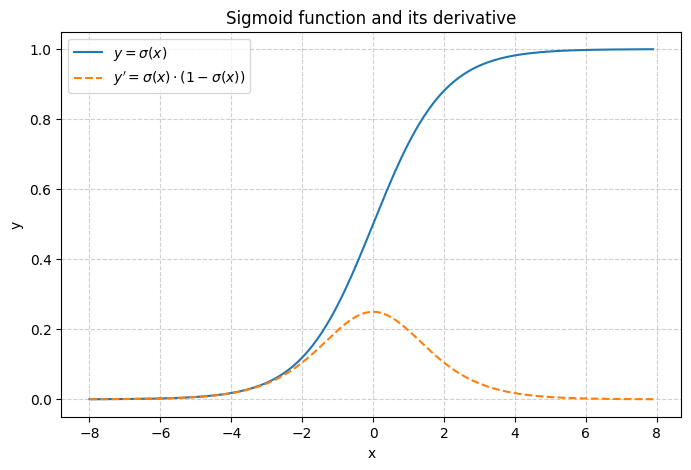

In [2]:
import mindspore.ops as ops
import matplotlib.pyplot as plt

def forward(x):
    return ops.sigmoid(x)

x = ops.arange(-8.0, 8.0, 0.1)
y = forward(x)
y_prime = mindspore.grad(forward)(x)
x, y, y_prime = x.asnumpy(), y.asnumpy(), y_prime.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(x, y, label='$y = \\sigma(x)$', linestyle='-')
plt.plot(x, y_prime, label='$y\' = \\sigma(x) \\cdot (1 - \\sigma(x))$', linestyle='--')

plt.title('Sigmoid function and its derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

As can be seen from the graph above, the gradient of the sigmoid function approaches zero for both large positive and negative values. In deep neural networks, such values are especially common due to repeated matrix multiplication. Therefore, compounded with precision loss, the computed gradients become effectively zero and the model weights fail to be updated, causing the learning process to stagnate beyond a certain threshold.

The ReLU activation function we saw in earlier chapters does not have this vanishing gradients issue and is the standard for most modern deep neural networks.

### 5.4.1.2. Exploding Gradients

This is the opposite phenomenon of vanishing gradients and has nothing to do with precision. When calculating gradients across a deep neural network, large values can grow exponentially through repeated multiplication causing the model weights to diverge. This breaks the training process and our model is not able to learn any useful information from our data.

Consider an initial $4 \times 4$ matrix of randomly initialized weights with mean $\mu = 0$ and variance $\sigma^2 = 1$. When we multiply this matrix with $100$ matrices with similar properties, the entries in our resulting matrix become prohibitively large.

We'll use [`mindspore.ops.standard_normal`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/ops/mindspore.ops.standard_normal.html) to generate our $4 \times 4$ matrix with the desired distribution.

In [3]:
from mindspore import dtype as mstype

shape = (4, 4)
M = ops.standard_normal(shape=shape).astype(dtype=mstype.float16)
for _ in range(100):
    N = ops.standard_normal(shape=shape).astype(dtype=mstype.float16)
    M = ops.matmul(N, M)
M

Tensor(shape=[4, 4], dtype=Float16, value=
[[-6.5504e+04, -6.5504e+04,  6.5504e+04,  6.5504e+04],
 [-1.2536e+04, -1.2536e+04,  1.2536e+04,  1.2536e+04],
 [ 5.3520e+03,  5.3520e+03, -5.3520e+03, -5.3520e+03],
 [-1.5620e+03, -1.5620e+03,  1.5620e+03,  1.5620e+03]])

## 5.4.3. Summary

We saw in this chapter how vanishing and exploding gradients can plague deep neural networks and why it is important to carefully choose our initialization parameters and activation function to avoid such issues.